In [1]:
# 03_funnel
#
# 목적: 2월 만료 예측 코호트 안에서 거래 -> 이용 -> 반복이용 -> 자동갱신 -> 재구독 전환 퍼널을 만든다.
#
# 단계 정의:
#   1. 예측 대상: train.csv의 2월 만료 코호트 992,931명
#   2. 거래 보유: 2017-01-31까지 거래 피처가 존재하는 유저
#   3. 로그 활동: 2017-01-31까지 청취 로그가 존재하는 유저
#   4. 반복 이용: 관측 기간 활동일수(full_active_days) >= 7일인 유저
#   5. 자동 갱신: 거래 이력의 auto_renew_rate > 0인 유저
#   6. 재구독: 위 단계를 통과하고 is_churn=0인 유저
#
# 모든 단계는 동일한 992,931명 코호트 안에서 순차적 부분집합(AND)으로 계산한다.
#
# 입력: data/processed/model_table_enhanced_v2.csv
# 출력: 시각화, data/dashboard/funnel.csv (DB 적재용)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROCESSED_DIR = Path("../data/processed")
DASH_DATA = Path("../data/dashboard")
DASH_DATA.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid", {"grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7"})
plt.rcParams.update({
    "figure.dpi": 110,
    "font.family": "Malgun Gothic",
    "axes.unicode_minus": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "grid.color": "#e1e0d9",
    "text.color": "#0b0b0b",
})
SERIES_1 = "#2a78d6"
SERIES_2 = "#eb6834"
REPEAT_USAGE_THRESHOLD = 7

In [3]:
USECOLS = [
    "msno", "snapshot", "is_churn", "has_transaction_record",
    "has_log_activity", "full_active_days", "auto_renew_rate",
]
model_table = pd.read_csv(
    PROCESSED_DIR / "model_table_enhanced_v2.csv",
    usecols=USECOLS,
)

assert len(model_table) == 992931
assert model_table["msno"].duplicated().sum() == 0
assert model_table["snapshot"].eq("2017-01-31").all()
print(f"동일 예측 코호트: {len(model_table):,}명 / 이탈률: {model_table['is_churn'].mean():.2%}")

동일 예측 코호트: 992,931명 / 이탈률: 6.39%


In [4]:
stage1 = set(model_table["msno"])
stage2 = stage1 & set(model_table.loc[model_table["has_transaction_record"] == 1, "msno"])
stage3 = stage2 & set(model_table.loc[model_table["has_log_activity"] == 1, "msno"])
stage4 = stage3 & set(model_table.loc[model_table["full_active_days"] >= REPEAT_USAGE_THRESHOLD, "msno"])
stage5 = stage4 & set(model_table.loc[model_table["auto_renew_rate"] > 0, "msno"])
stage6 = stage5 & set(model_table.loc[model_table["is_churn"] == 0, "msno"])

funnel = pd.DataFrame({
    "stage": ["1. 예측 대상", "2. 거래 보유", "3. 로그 활동", "4. 반복 이용", "5. 자동 갱신", "6. 재구독"],
    "count": [len(stage1), len(stage2), len(stage3), len(stage4), len(stage5), len(stage6)],
    "denominator": [len(stage1), len(stage1), len(stage2), len(stage3), len(stage4), len(stage5)],
})
funnel["stage_conversion_pct"] = (funnel["count"] / funnel["denominator"] * 100).round(1)
funnel["overall_pct"] = (funnel["count"] / len(stage1) * 100).round(1)
funnel.to_csv(DASH_DATA / "funnel.csv", index=False)
print(f"DB 적재용 저장: {DASH_DATA / 'funnel.csv'}")
funnel

DB 적재용 저장: ..\data\dashboard\funnel.csv


,stage,count,denominator,stage_conversion_pct,overall_pct
0,1. 예측 대상,992931,992931,100.0,100.0
1,2. 거래 보유,990834,992931,99.8,99.8
2,3. 로그 활동,865459,990834,87.3,87.2
3,4. 반복 이용,820704,865459,94.8,82.7
4,5. 자동 갱신,724071,820704,88.2,72.9
5,6. 재구독,700089,724071,96.7,70.5


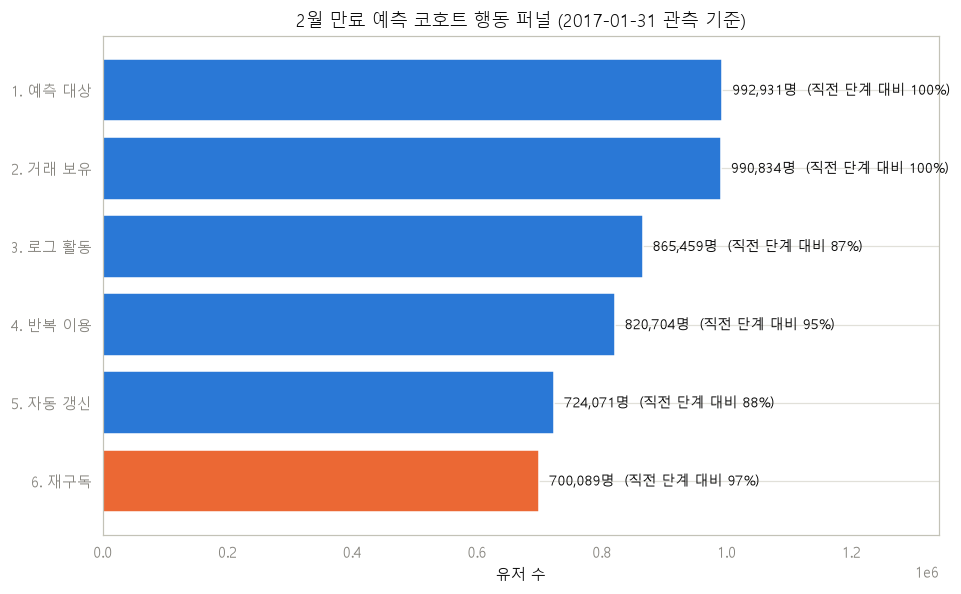

In [5]:
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = [SERIES_1] * 5 + [SERIES_2]
bars = ax.barh(funnel["stage"], funnel["count"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("유저 수")
ax.set_title("2월 만료 예측 코호트 행동 퍼널 (2017-01-31 관측 기준)")

for bar, row in zip(bars, funnel.itertuples()):
    label = f"{row.count:,}명"
    if row.stage_conversion_pct == row.stage_conversion_pct:  # not NaN
        label += f"  (직전 단계 대비 {row.stage_conversion_pct:.0f}%)"
    ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, "  " + label, va="center", fontsize=9)

ax.grid(axis="x")
ax.set_axisbelow(True)
ax.set_xlim(0, funnel["count"].max() * 1.35)
plt.tight_layout()
plt.show()

In [6]:
# ------------------------------------------------------------------
# 해석 시 주의할 점
# 1. 모든 단계는 2월 만료 예측 코호트 992,931명 안에서 계산하므로 모집단이 일관된다.
# 2. "반복 이용" 임계값(7일)은 임의로 정한 기준이며, 다른 기준을 쓰면 수치가 달라진다.
# 3. 가장 전환율이 낮은 단계가 어디인지가 "어디에 개선 여지가 있는가"에 대한 1차 힌트가 되지만,
#    상관관계 수준의 관찰이며 인과관계를 증명하는 것은 아니다.
# ------------------------------------------------------------------
print("퍼널 분석 완료 (위 주석의 해석 주의사항 참고)")

퍼널 분석 완료 (위 주석의 해석 주의사항 참고)
